In [115]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [116]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4941, 3)
(4941, 8)
(5150, 8)
1       78360.0
2       38730.0
3       47715.0
4       68805.0
5       82695.0
         ...   
3045    86310.0
3046    59085.0
3047    33915.0
3048    59280.0
3049    35265.0
Name: time_to_next_ev_hr, Length: 2964, dtype: float64
   tide_deriv  form_fac  slip_size  high_t_evt  tide_height  time_since
1    0.056003  1.826057  -1.811724           1    33.714046     61950.0
2   -0.032735  1.560612  -1.110816           1     5.033164     78165.0
3   -0.056060  1.590570  -2.703974           0   -35.730665     39015.0
4   -0.121354  1.590570  -1.704758           0    -3.994414     47850.0
5   -0.012976  2.166519  -1.519707           1    21.697819     72015.0


In [117]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

optimization = optuna.create_study(direction="minimize") #Finding the parameters that minimize the MAE
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-01-31 11:12:12,475] A new study created in memory with name: no-name-3345fd7a-d2d6-45ef-be63-d80c02ba62dd
[I 2026-01-31 11:12:13,196] Trial 0 finished with value: 1.1198464888102462 and parameters: {'learning_rate': 0.020204596555641115, 'max_depth': 4, 'subsample': 0.7579470360265519, 'colsample_bytree': 0.62284873914822}. Best is trial 0 with value: 1.1198464888102462.
[I 2026-01-31 11:12:14,092] Trial 1 finished with value: 1.1328938630406789 and parameters: {'learning_rate': 0.025128022642474702, 'max_depth': 5, 'subsample': 0.6605234200639474, 'colsample_bytree': 0.8222595574283152}. Best is trial 0 with value: 1.1198464888102462.
[I 2026-01-31 11:12:14,957] Trial 2 finished with value: 1.158302128234919 and parameters: {'learning_rate': 0.08928522449037707, 'max_depth': 5, 'subsample': 0.7061939952169558, 'colsample_bytree': 0.759072122766344}. Best is trial 0 with value: 1.1198464888102462.
[I 2026-01-31 11:12:15,424] Trial 3 finished with value: 1.7067519983127468 and p

Optimal Parameters: {'learning_rate': 0.011413434485227126, 'max_depth': 5, 'subsample': 0.8934485848722988, 'colsample_bytree': 0.8111342477428506}
XGBoost Error: 1.0966281907706297
Mean XGBoost Error: 0.9372846862934425


[[ 0.7605794   0.92192706 -1.72417447 -0.25297722  0.73637726 -1.83271743
  -0.20530632  0.60656573 -1.90605728 -0.52286784  0.88232354 -1.37727701
  -0.99737663  0.77231378 -0.81329362 -1.40954654 -0.55367058 -1.01644498
  -0.16496941 -0.16570281  1.507179    0.82658526  0.87205596  0.93146124
   0.95639678  0.96226397  0.93366143  1.00113409  0.79431573  1.03707061
   0.29927179  0.73931085  0.54496027  1.05467217  0.8067835   1.21822002
   0.91165948 -1.96179556 -0.18990496  0.88085675 -1.71757388 -0.24124285
   0.45988605 -1.8004479  -0.57933952  0.72977667  0.947596   -0.72308561
  -1.44401627 -0.17523699  0.61463312 -1.5210231   0.39754718 -0.46126238
  -1.61929849 -0.39158952  1.04513799  0.95933038  0.90799249  1.02093584
   0.88599053  1.03413702  0.8082503   0.66303741  0.08365266 -0.69301628
  -0.67394792 -0.45539519  1.1800833   0.88599053 -1.79091372 -0.31824968
   0.97619854  1.05173858  0.95492999 -1.20786197 -0.56980534 -0.16716961
  -1.63469986  0.14085773  0.1584593  

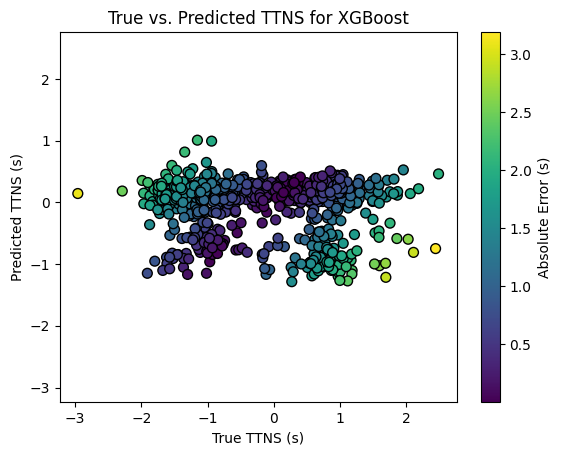

In [124]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
y_test_secs = y_test.reshape(1,-1)
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

 95%|=================== | 937/989 [00:12<00:00]       

XG Boost Drivers: form_fac       0.224569
tide_deriv     0.191977
tide_height    0.191622
time_since     0.171398
slip_size      0.135248
high_t_evt     0.021006
dtype: float64


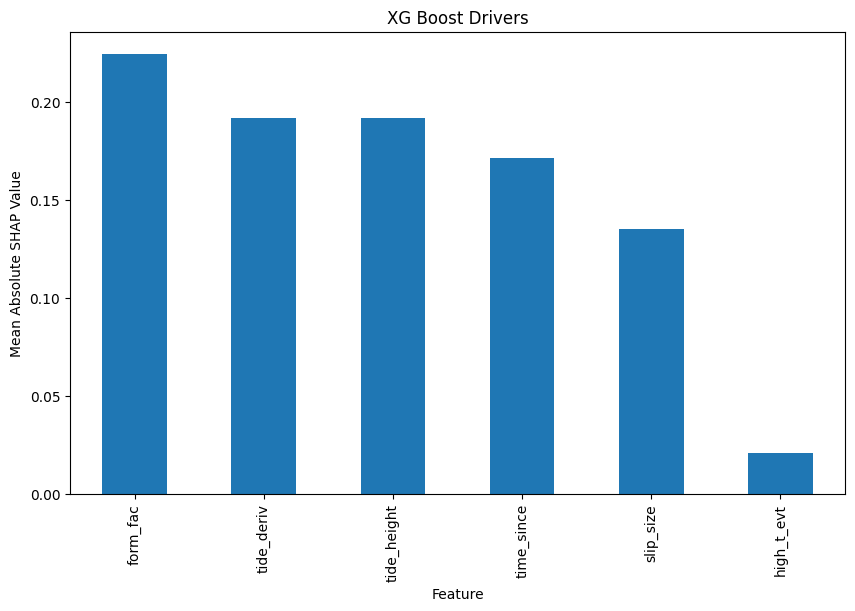

In [ ]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
